City swtiches to DNA testing - 
https://www.sciencedirect.com/science/article/pii/S016770122030230X

https://statescoop.com/machine-learning-algorithm-triples-e-coli-prediction-rate-on-chicago-beaches/



In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
datapath = "data/"

In [3]:
#pathogen sampling data, what we hope to predict in the model
raw_beach_lab_data = pd.read_csv(datapath + "Beach_Lab_Data_20260422.csv", low_memory=False)
# print(raw_beach_lab_data.size)
# print(raw_beach_lab_data.columns)

#these numbers are 17905, 17856 and 17963 respectively
# print(f"number of lines with s1 culture reading: {raw_beach_lab_data['Culture Sample 1 Reading'].notna().sum()}")
# print(f"number of lines with s2 culture reading: {raw_beach_lab_data['Culture Sample 2 Reading'].notna().sum()}")
# print(f"number of lines with mean culture reading: {raw_beach_lab_data['Culture Reading Mean'].notna().sum()}")

#timestamps EDA for pathogen DNA data
# raw_beach_lab_data['DNA Sample Timestamp'].describe()
# raw_beach_lab_data['DNA Sample Timestamp'].tail
# raw_beach_lab_data['DNA Sample Timestamp'].unique()
# raw_beach_lab_data['DNA Sample Timestamp'].value_counts() #2018 dates only have dates no specific timestamp, this should be made into just the date

# raw_beach_lab_data['Culture Note'].unique() # no notes
# raw_beach_lab_data['DNA Sample 2 Reading'].unique() #1731
# raw_beach_lab_data['DNA Sample 1 Reading'].unique() #2188
# raw_beach_lab_data['DNA Reading Mean'].unique() # 4761



In [4]:
beaches = ['Hartigan (Albion)', 'Leone', 'Marion Mahony Griffin (Jarvis)',
       'Osterman', 'Foster', 'Humboldt', 'Montrose', 'North Avenue',
       'Oak Street', 'Ohio Street', '12th Street', '57th Street',
       '63rd Street', 'Margaret T Burroughs (31st)', 'Oakwood',
       'South Shore', 'Calumet', 'Rainbow', 'Howard', 'Rogers', 'Juneway',
       'Fargo', 'Hartigan', 'Montrose Dog', 'Margaret T Burroughs',
       'Marion Mahony Griffin', 'Columbia', 'Lane', 'Loyola',
       'North Shore']

raw_beach_lab_data


,DNA Test ID,DNA Sample Timestamp,Beach,DNA Sample 1 Reading,DNA Sample 2 Reading,DNA Reading Mean,Culture Test ID,Culture Sample 1 Timestamp,Culture Sample 1 Reading,Culture Sample 2 Reading,Culture Reading Mean,Culture Note,Culture Sample Interval,Culture Sample 2 Timestamp,Latitude,Longitude,Location
0,29170.0,09/01/2025 12:04:00 PM,Hartigan (Albion),26.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.00270,-87.656400,"(42.0027, -87.6564)"
1,29171.0,09/01/2025 12:04:00 PM,Leone,131.0,NaN,131.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.01310,-87.663500,"(42.0131, -87.6635)"
2,29172.0,09/01/2025 12:04:00 PM,Marion Mahony Griffin (Jarvis),34.0,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.01610,-87.664700,"(42.0161, -87.6647)"
3,29169.0,09/01/2025 12:04:00 PM,Osterman,30.0,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.98770,-87.654500,"(41.9877, -87.6545)"
4,29168.0,09/01/2025 12:03:00 PM,Foster,16.0,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.97850,-87.651500,"(41.9785, -87.6515)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33064,NaN,NaN,Humboldt,NaN,NaN,NaN,114139.0,09/19/0016 10:00:00 AM,1.0,19.7,4.4,NaN,1.0,09/19/0016 10:01:00 AM,41.90643,-87.703717,"(41.90643, -87.703717)"
33065,NaN,NaN,Humboldt,NaN,NaN,NaN,114138.0,09/16/0016 09:55:00 AM,1.0,1.0,1.0,NaN,1.0,09/16/0016 09:56:00 AM,41.90643,-87.703717,"(41.90643, -87.703717)"
33066,NaN,NaN,Humboldt,NaN,NaN,NaN,114137.0,09/15/0016 09:55:00 AM,7.4,1.0,2.7,NaN,1.0,09/15/0016 09:56:00 AM,41.90643,-87.703717,"(41.90643, -87.703717)"
33067,NaN,NaN,Humboldt,NaN,NaN,NaN,114136.0,09/14/0016 08:30:00 AM,1.0,1.0,1.0,NaN,2.0,09/14/0016 08:32:00 AM,41.90643,-87.703717,"(41.90643, -87.703717)"


In [5]:
#do any columns have both culture and DNA readings
cultures_to_drop_df = raw_beach_lab_data.copy()

#if I omit all culture mean readings does it get rid of all culture data
my_cultures = duckdb.query("""
    SELECT
        COUNT(*)                                            AS total_rows,
        COUNT("Culture Reading Mean")                       AS has_culture_mean,
        COUNT("Culture Sample 1 Reading")                   AS has_culture_s1,
        COUNT("Culture Sample 2 Reading")                   AS has_culture_s2,
        COUNT("Culture Sample 1 Timestamp")                 AS has_culture_timestamp,

        -- rows with any culture data but no culture mean
        SUM(CASE WHEN "Culture Reading Mean" IS NULL AND (
                "Culture Sample 1 Reading" IS NOT NULL OR
                "Culture Sample 2 Reading" IS NOT NULL
            ) THEN 1 ELSE 0 END)                            AS culture_data_no_mean

    FROM cultures_to_drop_df
""").df()
display(my_cultures)

#find all rows that have culture data and see if they also have, this was probably not necessary could have just deleted any row that didn't have a DNA reading
culture_overlap = duckdb.query("""
SELECT
    SUM(CASE WHEN "DNA Reading Mean" IS NOT NULL THEN 1
            WHEN "DNA Sample 1 Reading" IS NOT NULL THEN 1
            WHEN "DNA Sample 2 Reading" IS NOT NULL THEN 1 
            ELSE 0 
            END) as dna_overlap_count_per_row
    FROM cultures_to_drop_df 
    WHERE "Culture Reading Mean" IS NOT NULL OR "Culture Sample 1 Reading" IS NOT NULL OR "Culture Sample 2 Reading" IS NOT NULL
                                                       
""").df()
display(culture_overlap)


,total_rows,has_culture_mean,has_culture_s1,has_culture_s2,has_culture_timestamp,culture_data_no_mean
0,33069,17963,17905,17853,18002,39.0


,dna_overlap_count_per_row
0,629.0


In [6]:
#finding non numeric columns
processed_beach_lab_data = raw_beach_lab_data.copy()
dna_cols = processed_beach_lab_data[['DNA Sample 1 Reading', 'DNA Sample 2 Reading', 'DNA Reading Mean']]
for col in dna_cols:
    # find values that can't be converted to numeric
    mask = pd.to_numeric(raw_beach_lab_data[col], errors='coerce').isna() & raw_beach_lab_data[col].notna()
    bad_vals = raw_beach_lab_data.loc[mask, col].unique()
    print(f"{col}: {bad_vals}")

DNA Sample 1 Reading: ['11,509.0' '1,825.0' '1,020.0' ... '1,769.2' '1,493.8' '4,508.7']
DNA Sample 2 Reading: ['9,022.0' '8,334.0' '1,314.0' '2,413.0' '1,165.0' '5,221.0' '3,260.0'
 '7,904.0' '1,928.0' '3,001.0' '2,143.0' '1,312.0' '10,256.0' '1,283.0'
 '2,072.0' '4,771.0' '1,344.0' '1,432.0' '1,315.0' '1,426.0' '8,072.0'
 '1,220.0' '1,581.0' '1,522.0' '1,893.0' '2,444.0' '2,615.0' '2,211.0'
 '8,674.0' '1,256.0' '1,141.0' '1,654.0' '3,590.0' '16,996.0' '3,349.0'
 '1,725.0' '3,248.0' '1,862.0' '1,558.0' '2,602.0' '1,631.0' '2,081.0'
 '1,709.0' '1,291.0' '17,979.0' '4,754.0' '2,056.0' '2,619.0' '1,591.0'
 '6,828.0' '1,601.0' '1,700.0' '1,734.0' '1,498.0' '5,230.0' '3,182.0'
 '1,210.0' '3,544.0' '1,942.0' '2,813.0' '1,205.0' '3,468.0' '2,289.0'
 '2,791.0' '13,047.0' '4,410.0' '4,269.0' '1,627.0' '12,681.0' '12,466.0'
 '1,480.0' '1,194.0' '1,552.0' '1,399.0' '9,075.0' '1,182.0' '1,024.0'
 '1,405.0' '1,167.0' '1,296.0' '1,355.0' '1,486.0' '1,048.0' '2,065.0'
 '1,069.0' '3,596.0' '1,034.0' 

In [7]:
#we need to keep these high values, removing the comman
for col in ['DNA Sample 1 Reading', 'DNA Sample 2 Reading', 'DNA Reading Mean']:
    processed_beach_lab_data[col] = pd.to_numeric(
        processed_beach_lab_data[col].astype(str).str.replace(',', '', regex=False),
        errors='coerce'
    )

In [8]:
processed_beach_lab_data['DNA Reading Mean'].describe()

count     15696.000000
mean        488.250210
std        4000.886504
min           0.000000
25%          33.900000
50%         100.000000
75%         288.000000
max      326671.000000
Name: DNA Reading Mean, dtype: float64

In [9]:
for col in dna_cols:
    # find values that can't be converted to numeric
    mask = pd.to_numeric(processed_beach_lab_data[col], errors='coerce').isna() & processed_beach_lab_data[col].notna()
    bad_vals = processed_beach_lab_data.loc[mask, col].unique()
    print(f"{col}: {bad_vals}")

DNA Sample 1 Reading: []
DNA Sample 2 Reading: []
DNA Reading Mean: []


In [10]:
#dropping unneeded columns, converting test readings to numeric and unparsable strings to NaN
df_for_selection = raw_beach_lab_data.copy()
# df_for_selection = df_for_selection[['DNA Test ID', 'DNA Sample Timestamp', 'Beach', 'DNA Sample 1 Reading', 'DNA Sample 2 Reading', 'DNA Reading Mean', 'Latitude', 'Longitude', 'Location']]
for col in ['DNA Sample 1 Reading', 'DNA Sample 2 Reading', 'DNA Reading Mean']:
    df_for_selection[col] = pd.to_numeric(df_for_selection[col].astype(str).str.replace(',', '', regex=False), errors='coerce') #coerce inserts NaN for all that cant be converted to numeric
df_for_selection.loc[
    (df_for_selection["DNA Sample 1 Reading"].notna())
    & (df_for_selection["DNA Sample 2 Reading"].notna())
    & (df_for_selection["DNA Reading Mean"].notna())
].head()

,DNA Test ID,DNA Sample Timestamp,Beach,DNA Sample 1 Reading,DNA Sample 2 Reading,DNA Reading Mean,Culture Test ID,Culture Sample 1 Timestamp,Culture Sample 1 Reading,Culture Sample 2 Reading,Culture Reading Mean,Culture Note,Culture Sample Interval,Culture Sample 2 Timestamp,Latitude,Longitude,Location
3530,22933.0,05/27/2024 11:22:00 AM,Rainbow,634.0,634.0,634.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.7580,-87.5510,"(41.758, -87.551)"
3532,22913.0,05/27/2024 11:21:00 AM,Calumet,298.0,298.0,298.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.7142,-87.5299,"(41.7142, -87.5299)"
8765,13835.0,07/07/2020 12:42:00 PM,12th Street,96.0,12.0,33.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.8638,-87.6083,"(41.8638, -87.6083)"
8766,13833.0,07/07/2020 12:42:00 PM,57th Street,7044.0,9022.0,7971.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.7911,-87.5797,"(41.7911, -87.5797)"
8767,13792.0,07/07/2020 12:42:00 PM,63rd Street,10948.0,8334.0,9552.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.7827,-87.5748,"(41.7827, -87.5748)"


In [11]:
df_for_selection['DNA Reading Mean'].describe()

count     15696.000000
mean        488.250210
std        4000.886504
min           0.000000
25%          33.900000
50%         100.000000
75%         288.000000
max      326671.000000
Name: DNA Reading Mean, dtype: float64

In [12]:
# = dropping rows that don't have DNA data
#uses df_for_selection that is made above
dna_testing_df = duckdb.query("""
    SELECT *
    FROM df_for_selection
    WHERE "DNA Reading Mean" IS NOT NULL OR "DNA Sample 1 Reading" IS NOT NULL OR "DNA Sample 2 Reading" IS NOT NULL                         
""").df()

#making sure we kept all the culture overlaps
culture_overlap_2 = duckdb.query("""
SELECT
    SUM(CASE WHEN "DNA Reading Mean" IS NOT NULL THEN 1
            WHEN "DNA Sample 1 Reading" IS NOT NULL THEN 1
            WHEN "DNA Sample 2 Reading" IS NOT NULL THEN 1 
            ELSE 0 
            END) as dna_overlap_count_per_row
    FROM dna_testing_df 
    WHERE "Culture Reading Mean" IS NOT NULL OR "Culture Sample 1 Reading" IS NOT NULL OR "Culture Sample 2 Reading" IS NOT NULL
                                                       
""").df()
display(culture_overlap_2)
# pandas option
# dna_testing_df = raw_beach_lab_data.copy()
# s1 = dna_testing_df['DNA Sample 1 Reading']
# s2 = dna_testing_df['DNA Sample 2 Reading']
# both = s1.notna() & s2.notna()
# s1_only     = s1.notna() & s2.isna()
# s2_only     = s2.notna() & s1.isna()
# mean_only   = mean.notna() & s1.isna() & s2.isna()
# all_missing = s1.isna() & s2.isna() & mean.isna()


,dna_overlap_count_per_row
0,629.0


In [13]:
#making year, month, and day columns. 
dna_testing_df['year'] = pd.to_datetime(dna_testing_df['DNA Sample Timestamp'], errors='coerce').dt.year
dna_testing_df['month'] = pd.to_datetime(dna_testing_df['DNA Sample Timestamp'], errors='coerce').dt.month
dna_testing_df['day'] = pd.to_datetime(dna_testing_df['DNA Sample Timestamp'], errors='coerce').dt.day

#how many dates didn't parse
failed_rows = []

for idx, row in dna_testing_df.iterrows():
    if pd.isna(row['year']):
        failed_rows.append({
            'index': idx,
            'DNA Test ID': row['DNA Test ID'],
            'DNA Sample Timestamp': row['DNA Sample Timestamp'],
            'year': row['year'],
            'month': row['month'],
            'day': row['day']
        })
print(f"Failed to parse: {len(failed_rows)}")
pd.DataFrame(failed_rows) #there were only 19 all from a single misentered date, dropping

dna_testing_df = dna_testing_df[dna_testing_df['year'].notna()].copy()



Failed to parse: 19


In [14]:
# Check what years have dual-replicate data
yearly_dual = dna_testing_df[dna_testing_df['DNA Sample 2 Reading'].notna()].groupby('year').size()
print("Dual-replicate samples by year:")
print(yearly_dual)

Dual-replicate samples by year:
year
2015.0     271
2016.0     626
2017.0    1995
2018.0    1959
2019.0    1963
2020.0      47
2024.0       2
dtype: int64


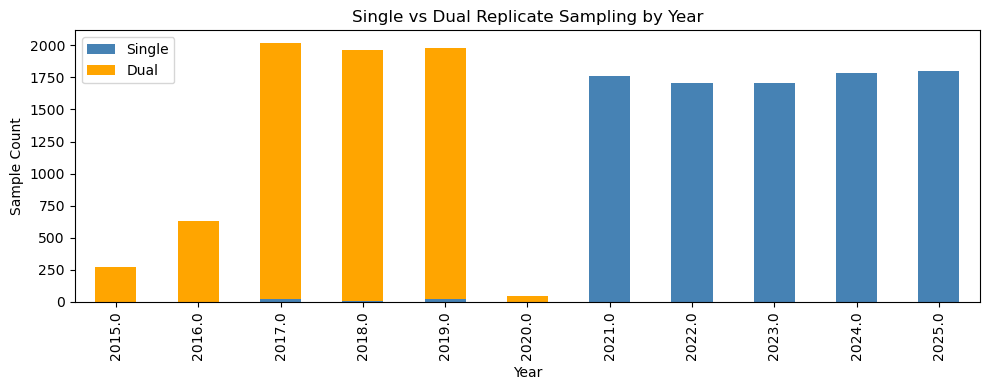

In [15]:
yearly = dna_testing_df.groupby('year').agg(
    dual=('DNA Sample 2 Reading', 'count'),
    total=('DNA Reading Mean', 'count')
)
yearly['single'] = yearly['total'] - yearly['dual']

yearly[['single', 'dual']].plot(kind='bar', stacked=True, figsize=(10, 4),
    color=['steelblue', 'orange'], title='Single vs Dual Replicate Sampling by Year')
plt.ylabel('Sample Count')
plt.xlabel('Year')
plt.legend(['Single', 'Dual'])
plt.tight_layout()
plt.show()


In [16]:
# which columns have values? Make a new column in which all the readings are consolidated
s1 = dna_testing_df['DNA Sample 1 Reading']
s2 = dna_testing_df['DNA Sample 2 Reading']
mean = dna_testing_df['DNA Reading Mean']
both = s1.notna() & s2.notna()
s1_only     = s1.notna() & s2.isna()
s2_only     = s2.notna() & s1.isna()
mean_only   = mean.notna() & s1.isna() & s2.isna()
all_missing = s1.isna() & s2.isna() & mean.isna()


dna_testing_df['reading'] = np.where(
    both,
    np.sqrt(s1 * s2), #geometric mean, what is used in the data when two measurements are taken
    s1.fillna(s2).fillna(dna_testing_df['DNA Reading Mean'])  # fallback to recorded mean
)

dna_testing_df['reading_std'] = dna_testing_df[
    ['DNA Sample 1 Reading', 'DNA Sample 2 Reading']
].std(axis=1)

dna_testing_df['dual_reading'] = both.astype(int) #binary marker for when both s1 and s2 have readings

print(f"Both S1 and S2:          {both.sum():>6}")
print(f"S1 only:                 {s1_only.sum():>6}")
print(f"S2 only:                 {s2_only.sum():>6}")
print(f"Mean only (no S1 or S2): {mean_only.sum():>6}")
print(f"All three missing:       {all_missing.sum():>6}")
print(f"─────────────────────────────")
print(f"Total rows:              {len(dna_testing_df):>6}")
print(f"reading NaN count: {dna_testing_df['reading'].isna().sum()}")
print(f"reading_std NaN count: {dna_testing_df['reading_std'].isna().sum()}")
print(f"dual_reading counts:\n{dna_testing_df['dual_reading'].value_counts()}")


Both S1 and S2:            6863
S1 only:                   8814
S2 only:                      0
Mean only (no S1 or S2):      0
All three missing:            0
─────────────────────────────
Total rows:               15677
reading NaN count: 0
reading_std NaN count: 8814
dual_reading counts:
dual_reading
0    8814
1    6863
Name: count, dtype: int64


In [17]:
dna_testing_df['DNA Reading Mean'].describe()

count     15677.000000
mean        488.786139
std        4003.280497
min           0.000000
25%          34.000000
50%         100.300000
75%         288.300000
max      326671.000000
Name: DNA Reading Mean, dtype: float64

In [18]:
#adding a column that indicates method for test (qPCR 2021 and on)
dna_testing_df['pre2021'] = dna_testing_df['year'].apply(
    lambda y: 0 if y >= 2021 else 1
)
#deleting the two dual readings in 2024
dna_testing_df = dna_testing_df[
    ~((dna_testing_df['year'] == 2024) & (dna_testing_df['dual_reading'] == 1))
].copy()

print(dna_testing_df['pre2021'].value_counts())
print(f"\nRows remaining: {len(dna_testing_df)}")

pre2021
0    8763
1    6912
Name: count, dtype: int64

Rows remaining: 15675


In [19]:

dna_testing_df['Beach'] = dna_testing_df['Beach'].str.replace(" ", "_").str.replace("(","").str.replace(")","").str.lower()
print(dna_testing_df['Beach'].unique())

['hartigan_albion' 'leone' 'marion_mahony_griffin_jarvis' 'osterman'
 'foster' 'humboldt' 'montrose' 'north_avenue' 'oak_street' 'ohio_street'
 '12th_street' '57th_street' '63rd_street' 'margaret_t_burroughs_31st'
 'oakwood' 'south_shore' 'calumet' 'rainbow' 'howard' 'rogers']


We have pathogen readings from 5/26/2015 to 9/1/2026 but only summer, remember. Making a spine now:

In [20]:
# Build the model spine: one row per (date, beach) with the target variable
dna_readings_df = dna_testing_df[[
    'DNA Sample Timestamp', 'Beach', 'Latitude', 'Longitude', 'year',
    'reading', 'reading_std', 'dual_reading', 'pre2021'
]].copy()

# Strip timestamp down to date only for merging
dna_readings_df['timestamp_central'] = pd.to_datetime(
    dna_testing_df['DNA Sample Timestamp'], errors='coerce'
).dt.tz_localize('America/Chicago', nonexistent='NaT', ambiguous='NaT')

dna_readings_df = dna_readings_df.sort_values(['timestamp_central', 'Beach']).reset_index(drop=True)

print(f"Rows: {len(dna_readings_df)}")
print(f"Unique dates: {dna_readings_df['timestamp_central'].nunique()}")
print(f"Unique beaches: {dna_readings_df['Beach'].nunique()}")
print(f"Date range: {dna_readings_df['timestamp_central'].min()} to {dna_readings_df['timestamp_central'].max()}")
dna_readings_df.head()

Rows: 15675
Unique dates: 3767
Unique beaches: 20
Date range: 2015-05-26 00:00:00-05:00 to 2025-09-01 12:04:00-05:00


,DNA Sample Timestamp,Beach,Latitude,Longitude,year,reading,reading_std,dual_reading,pre2021,timestamp_central
0,05/26/2015 12:00:00 AM,63rd_street,41.7827,-87.5748,2015.0,129.992307,121.198102,1,1,2015-05-26 00:00:00-05:00
1,05/26/2015 12:00:00 AM,calumet,41.7142,-87.5299,2015.0,208.902082,199.191980,1,1,2015-05-26 00:00:00-05:00
2,05/26/2015 12:00:00 AM,montrose,41.9655,-87.6385,2015.0,94.978313,63.144636,1,1,2015-05-26 00:00:00-05:00
3,05/26/2015 12:00:00 AM,rainbow,41.7580,-87.5510,2015.0,157.857151,67.670119,1,1,2015-05-26 00:00:00-05:00
4,05/26/2015 12:00:00 AM,south_shore,41.7689,-87.5636,2015.0,147.466945,143.613387,1,1,2015-05-26 00:00:00-05:00


In [30]:
#dropping beach reading for beached that don't have geomorphology data
dna_readings_df = dna_readings_df[~dna_readings_df['Beach'].isin(['calumet','marion_mahony_griffin_jarvis','hartigan_albion','12th_street'])]
dna_readings_df

,DNA Sample Timestamp,Beach,Latitude,Longitude,year,reading,reading_std,dual_reading,pre2021,timestamp_central
0,05/26/2015 12:00:00 AM,63rd_street,41.7827,-87.5748,2015.0,129.992307,121.198102,1,1,2015-05-26 00:00:00-05:00
2,05/26/2015 12:00:00 AM,montrose,41.9655,-87.6385,2015.0,94.978313,63.144636,1,1,2015-05-26 00:00:00-05:00
3,05/26/2015 12:00:00 AM,rainbow,41.7580,-87.5510,2015.0,157.857151,67.670119,1,1,2015-05-26 00:00:00-05:00
4,05/26/2015 12:00:00 AM,south_shore,41.7689,-87.5636,2015.0,147.466945,143.613387,1,1,2015-05-26 00:00:00-05:00
5,05/27/2015 12:00:00 AM,63rd_street,41.7827,-87.5748,2015.0,123.773664,329.936024,1,1,2015-05-27 00:00:00-05:00
...,...,...,...,...,...,...,...,...,...,...
15668,09/01/2025 12:03:00 PM,north_avenue,41.9148,-87.6273,2025.0,253.000000,NaN,0,0,2025-09-01 12:03:00-05:00
15669,09/01/2025 12:03:00 PM,oak_street,41.9032,-87.6235,2025.0,544.000000,NaN,0,0,2025-09-01 12:03:00-05:00
15670,09/01/2025 12:03:00 PM,ohio_street,41.8935,-87.6152,2025.0,43.000000,NaN,0,0,2025-09-01 12:03:00-05:00
15672,09/01/2025 12:04:00 PM,leone,42.0131,-87.6635,2025.0,131.000000,NaN,0,0,2025-09-01 12:04:00-05:00


In [31]:
dna_readings_df.to_parquet("data/prepared_data/dna_readings.parquet", index=False)

Below is to better undestand these readings:

In [22]:
dna_readings_df.sort_values('reading', ascending=False)

,DNA Sample Timestamp,Beach,Latitude,Longitude,year,reading,reading_std,dual_reading,pre2021,timestamp_central
15089,07/30/2025 11:40:00 AM,humboldt,41.90643,-87.703717,2025.0,326671.000000,NaN,0,0,2025-07-30 11:40:00-05:00
13724,08/24/2024 11:26:00 AM,humboldt,41.90643,-87.703717,2024.0,174595.000000,NaN,0,0,2024-08-24 11:26:00-05:00
13137,07/22/2024 11:31:00 AM,humboldt,41.90643,-87.703717,2024.0,122671.000000,NaN,0,0,2024-07-22 11:31:00-05:00
8363,08/19/2021 12:08:00 PM,humboldt,41.90643,-87.703717,2021.0,118370.000000,NaN,0,0,2021-08-19 12:08:00-05:00
4336,08/06/2018 12:00:00 AM,rogers,42.02130,-87.666600,2018.0,108022.398511,31661.413234,1,1,2018-08-06 00:00:00-05:00
...,...,...,...,...,...,...,...,...,...,...
10468,05/30/2023 12:09:00 PM,marion_mahony_griffin_jarvis,42.01610,-87.664700,2023.0,0.000000,NaN,0,0,2023-05-30 12:09:00-05:00
11800,08/18/2023 11:55:00 AM,12th_street,41.86380,-87.608300,2023.0,0.000000,NaN,0,0,2023-08-18 11:55:00-05:00
11823,08/19/2023 12:30:00 PM,oak_street,41.90320,-87.623500,2023.0,0.000000,NaN,0,0,2023-08-19 12:30:00-05:00
11668,08/10/2023 11:41:00 AM,12th_street,41.86380,-87.608300,2023.0,0.000000,NaN,0,0,2023-08-10 11:41:00-05:00


Readings > 1000: 1170

--- 12th_street (34 readings) ---


,timestamp_central,reading,dual_reading,pre2021
3229,2018-06-10 00:00:00-05:00,94601.507430,1,1
3817,2018-07-11 00:00:00-05:00,61062.540440,1,1
1988,2017-07-20 00:00:00-05:00,17325.351771,1,1
674,2016-07-30 13:02:00-05:00,5992.376407,1,1
2065,2017-07-24 00:00:00-05:00,5839.711123,1,1
14843,2025-07-17 11:20:00-05:00,5166.000000,0,0
4418,2018-08-11 00:00:00-05:00,4489.772155,1,1
13277,2024-07-30 11:17:00-05:00,3640.000000,0,0
14916,2025-07-21 11:27:00-05:00,3069.000000,0,0
4584,2018-08-20 00:00:00-05:00,3012.730987,1,1


--- 57th_street (37 readings) ---


,timestamp_central,reading,dual_reading,pre2021
13803,2024-08-29 11:46:00-05:00,9897.000000,0,0
6896,2020-07-07 12:42:00-05:00,7971.886101,1,1
14499,2025-06-28 11:20:00-05:00,5700.000000,0,0
4765,2018-08-29 11:32:00-05:00,5142.152273,1,1
4018,2018-07-21 00:00:00-05:00,4340.511491,1,1
3938,2018-07-17 11:31:00-05:00,3696.106059,1,1
7139,2021-06-11 11:46:00-05:00,2078.000000,0,0
1251,2017-06-13 00:00:00-05:00,2036.163058,1,1
2066,2017-07-24 00:00:00-05:00,1950.852122,1,1
2262,2017-08-03 00:00:00-05:00,1859.017482,1,1


--- 63rd_street (132 readings) ---


...

,timestamp_central,reading,dual_reading,pre2021
7102,2021-06-09 11:40:00-05:00,22408.000000,0,0
10438,2023-05-29 12:04:00-05:00,22016.000000,0,0
6308,2019-08-06 11:48:00-05:00,16930.373298,1,1
4375,2018-08-08 12:36:00-05:00,14641.641028,1,1
15395,2025-08-17 12:05:00-05:00,12754.000000,0,0
...,...,...,...,...
13168,2024-07-24 11:04:00-05:00,1096.000000,0,0
5610,2019-07-01 12:10:00-05:00,1084.120381,1,1
15308,2025-08-12 11:43:00-05:00,1053.000000,0,0
2004,2017-07-20 00:00:00-05:00,1043.333120,1,1


--- rogers (46 readings) ---


,timestamp_central,reading,dual_reading,pre2021
4336,2018-08-06 00:00:00-05:00,108022.398511,1,1
4602,2018-08-20 00:00:00-05:00,71817.514828,1,1
3107,2018-06-03 12:33:00-05:00,18918.074902,1,1
4561,2018-08-18 00:00:00-05:00,8477.433928,1,1
2834,2017-08-31 00:00:00-05:00,5612.325721,1,1
3737,2018-07-06 12:29:00-05:00,4273.918577,1,1
4376,2018-08-08 12:36:00-05:00,4254.082510,1,1
2874,2017-09-02 00:00:00-05:00,3325.395465,1,1
2162,2017-07-28 00:00:00-05:00,2828.000000,0,1
5987,2019-07-20 12:02:00-05:00,2617.081199,1,1


--- south_shore (79 readings) ---


,timestamp_central,reading,dual_reading,pre2021
9319,2022-07-04 11:25:00-05:00,40460.000000,0,0
15074,2025-07-30 11:34:00-05:00,21491.000000,0,0
4843,2018-09-01 00:00:00-05:00,12046.074049,1,1
13401,2024-08-06 11:41:00-05:00,10792.000000,0,0
3068,2018-06-01 00:00:00-05:00,8739.297455,1,1
...,...,...,...,...
3607,2018-06-29 00:00:00-05:00,1026.401481,1,1
1888,2017-07-14 00:00:00-05:00,1025.639313,1,1
4417,2018-08-10 00:00:00-05:00,1013.650827,1,1
9,2015-05-27 00:00:00-05:00,1006.842217,1,1


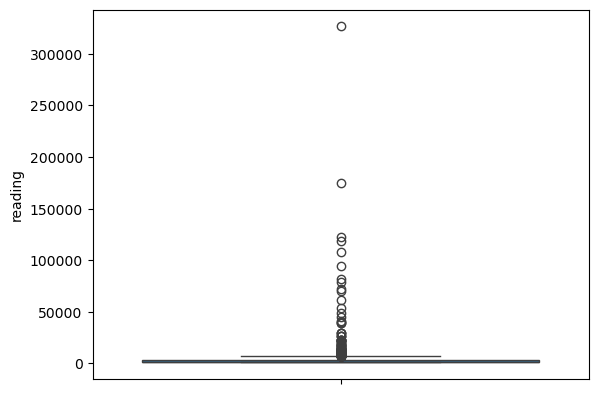

In [23]:
over_1000_df = dna_readings_df[dna_readings_df['reading'] > 1000].sort_values('reading', ascending=False)
print(f"Readings > 1000: {len(over_1000_df)}\n")
sns.boxplot(over_1000_df['reading'])

for beach, group in over_1000_df.groupby('Beach'):
    print(f"--- {beach} ({len(group)} readings) ---")
    display(group[['timestamp_central', 'reading', 'dual_reading', 'pre2021']])

    


In [24]:
threshold = 1000
summary = duckdb.query(f"""
    SELECT
        Beach,
        COUNT(*) FILTER (WHERE reading > {threshold})  AS n_exceedances,
        COUNT(*)                                        AS total_readings,
        ROUND(MAX(reading), 1)                         AS max_reading,
        ROUND(AVG(reading), 1)                         AS mean_reading,
        MIN(timestamp_central)                         AS first,
        MAX(timestamp_central)                         AS last
    FROM dna_readings_df
    WHERE year >= 2021
    GROUP BY Beach
    HAVING COUNT(*) FILTER (WHERE reading > {threshold}) > 0
    ORDER BY n_exceedances DESC
""").df()

detail = duckdb.query(f"""
    SELECT Beach, timestamp_central, ROUND(reading, 1) AS reading, pre2021
    FROM dna_readings_df
    WHERE reading > {threshold} AND year >= 2021
    ORDER BY Beach, reading DESC
""").df()

display(summary)
display(detail)

,Beach,n_exceedances,total_readings,max_reading,mean_reading,first,last
0,63rd_street,54,497,69800.0,594.5,2021-05-28 12:03:00-05:00,2025-09-01 12:02:00-05:00
1,montrose,51,503,29479.0,552.3,2021-05-28 12:06:00-05:00,2025-09-01 12:03:00-05:00
2,calumet,49,502,19776.0,439.4,2021-05-29 12:22:00-05:00,2025-09-01 12:01:00-05:00
3,margaret_t_burroughs_31st,43,494,13991.0,454.4,2021-05-28 12:05:00-05:00,2025-09-01 12:02:00-05:00
4,ohio_street,42,505,9760.0,354.1,2021-05-28 12:06:00-05:00,2025-09-01 12:03:00-05:00
5,humboldt,37,212,326671.0,5123.9,2021-06-25 12:09:00-05:00,2025-09-01 12:03:00-05:00
6,rainbow,27,508,22408.0,349.7,2021-05-28 11:58:00-05:00,2025-09-01 12:01:00-05:00
7,marion_mahony_griffin_jarvis,27,507,22903.0,323.7,2021-05-29 12:28:00-05:00,2025-09-01 12:04:00-05:00
8,south_shore,26,507,40460.0,426.6,2021-05-28 12:01:00-05:00,2025-09-01 12:02:00-05:00
9,hartigan_albion,20,508,12285.0,235.2,2021-05-28 12:07:00-05:00,2025-09-01 12:04:00-05:00


,Beach,timestamp_central,reading,pre2021
0,12th_street,2025-07-17 11:20:00-05:00,5166.0,0
1,12th_street,2024-07-30 11:17:00-05:00,3640.0,0
2,12th_street,2025-07-21 11:27:00-05:00,3069.0,0
3,12th_street,2022-08-12 11:24:00-05:00,2850.0,0
4,12th_street,2025-06-10 11:37:00-05:00,2565.0,0
...,...,...,...,...
479,south_shore,2022-07-16 10:56:00-05:00,1184.0,0
480,south_shore,2021-06-26 11:40:00-05:00,1137.0,0
481,south_shore,2021-08-13 11:34:00-05:00,1131.0,0
482,south_shore,2023-06-11 12:02:00-05:00,1060.0,0


these outliers are fine, bacterial counts are often log-normal

Notes for joining other datasets, city of chicago data are assumed to be in Central Time, the timestamps are floating and can be assumed to be the exact time that happened on that day. https://dev.socrata.com/docs/datatypes/floating_timestamp.html#,

I'm going to implement a feature naming convention now: 
 Feature naming convention for this project:

     {source}_{variable}_{operation}_{window}

 - source:    where the data came from (coc, usgs, beach, season, etc.)

 - variable:  what's being measured (precip, temp, wind, etc.)

 - operation: how it was aggregated (sum, max, mean, count, lag)
 
 - window:    over what time period (24h, 7d, 6h)

 Examples:

   coc_precip_sum_24h     -> sum of COC precip over 24h before sample

   coc_precip_max_6h      -> max single-bucket COC precip in last 6h

   usgs_precip_sum_7d     -> sum of USGS precip over 7 days

   season_sin_doy         -> sin of day-of-year (no source/window needed)

 Rule: if you change ONE thing about a feature, only ONE slot in the
 name should change. This makes filtering by prefix easy.

In [25]:
#chicago beach weather portal https://dev.socrata.com/foundry/data.cityofchicago.org/k7hf-8y75
#data is just from foster and oak street air and may be faulty before memorial day?